In [2]:
%%writefile book_spider.py
## Here we prepare scrapy spider for our use

# We will create parse to get links from catalogue page
# And parse_book for book data from each book link
import scrapy

class SpideronBook(scrapy.Spider):
    name = "books"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/catalogue/page-1.html"]
    
    # We only want to scrape 5 pages to get exactly 100 books (20 per page)
    custom_settings = {
        'CLOSESPIDER_PAGECOUNT': 0, # We will handle page limits manually
    }
    
    def __init__(self, *args, **kwargs):
        super(SpideronBook, self).__init__(*args, **kwargs)
        self.page_count = 1

    def parse(self, response):
        # 1. Find all the book links on the current page
        books = response.css('h3 a::attr(href)').getall()
        
        # 2. Tell the spider to visit each book link
        for book_url in books:
            yield response.follow(book_url, callback=self.parse_book)

        # 3. Handle Pagination (Clicking the 'Next' button)
        next_page = response.css('li.next a::attr(href)').get()
        if next_page and self.page_count < 5:
            self.page_count += 1
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        # This function extracts data from the individual book page
        
        # This Extracts rating from the class name
        rating_class = response.css('p.star-rating::attr(class)').get()
        rating = rating_class.replace('star-rating ', '') if rating_class else 'None'
        
        # This Extracts availability and cleaning up the text
        availability = response.css('p.instock.availability::text').getall()
        availability = "".join(availability).strip()
        
        yield {
            'title': response.css('h1::text').get(),
            'category': response.css('ul.breadcrumb li:nth-child(3) a::text').get(),
            'price': response.css('p.price_color::text').get(),
            'rating': rating,
            'availability': availability,
            # Description is the paragraph right after the product_description div
            'product_description': response.xpath('//div[@id="product_description"]/following-sibling::p/text()').get(),
            # Information table extraction
            'upc': response.xpath('//th[text()="UPC"]/following-sibling::td/text()').get(),
            'number_of_reviews': response.xpath('//th[text()="Number of reviews"]/following-sibling::td/text()').get(),
            'product_url': response.url
        }

Writing book_spider.py


In [ ]:
!scrapy runspider book_spider.py -o books_data.csv

2026-08-06 23:02:50 [scrapy.utils.log] INFO: Scrapy 2.17.0 started (bot: scrapybot)
2026-08-06 23:02:50 [scrapy.utils.log] INFO: Versions:
{'lxml': '6.1.1',
 'libxml2': '2.11.9',
 'cssselect': '1.5.0',
 'parsel': '1.11.0',
 'w3lib': '2.4.1',
 'Twisted': '26.4.0',
 'Python': '3.12.4 (tags/v3.12.4:8e8a4ba, Jun  6 2024, 19:30:16) [MSC v.1940 '
           '64 bit (AMD64)]',
 'pyOpenSSL': '26.4.0 (OpenSSL 4.0.1 9 Jun 2026)',
 'cryptography': '50.0.0',
 'Platform': 'Windows-11-10.0.26200-SP0'}
2026-08-06 23:02:50 [scrapy.crawler] DEBUG: Using AsyncCrawlerProcess
2026-08-06 23:02:50 [asyncio] DEBUG: Using selector: SelectSelector
2026-08-06 23:02:50 [scrapy.addons] INFO: Enabled addons:
[]
2026-08-06 23:02:50 [scrapy.utils.log] DEBUG: Using reactor: twisted.internet.asyncioreactor.AsyncioSelectorReactor
2026-08-06 23:02:50 [scrapy.utils.log] DEBUG: Using asyncio event loop: asyncio.windows_events._WindowsSelectorEventLoop
2026-08-06 23:02:50 [scrapy.extensions.telnet] INFO: Telnet Password: 2

In [8]:
import pandas as pd

df = pd.read_csv('books_data.csv')

# Record totals - scraped records, missing values, and duplicate UPC values.
total_records = len(df)
duplicate_upcs = df.duplicated(subset=['upc']).sum()
missing_values = df.isnull().sum()

# Print
print("=== FINAL SCRAPING REPORT ===")
print(f"Total Books Scraped: {total_records}")
print(f"Duplicate UPCs: {duplicate_upcs}")
print("\nMissing Values per Column:")
print(missing_values)

=== FINAL SCRAPING REPORT ===
Total Books Scraped: 100
Duplicate UPCs: 0

Missing Values per Column:
title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
upc                    0
number_of_reviews      0
product_url            0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('books_data.csv')

# Clean extra text
df['title'] = df['title'].str.strip()
df['category'] = df['category'].str.strip()

# Remove duplicate books
df = df.drop_duplicates(subset=['upc'])

# Fill missing descriptions
df['product_description'] = df['product_description'].fillna("No description available.")

# Convert price to numeric
df['price'] = df['price'].str.replace(r'[^\d.]', '', regex=True).astype(float)

# Convert ratings to integers
rating_mapping = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
df['rating'] = df['rating'].map(rating_mapping)

# Extract stock count
df['stock_count'] = df['availability'].str.extract(r'(\d+)')[0].astype(int)

# Remove original availability column
df = df.drop(columns=['availability'])

# Create new features
df['description_word_count'] = df['product_description'].apply(lambda x: len(str(x).split()))

df['price_band'] = pd.cut(
    df['price'],
    bins=[0, 20, 40, 100],
    labels=['Budget', 'Moderate', 'Expensive']
) 

df['value_score'] = (df['rating'] / df['price']).round(3)

# Save cleaned data
df.to_csv('books_cleaned.csv', index=False)

# Some print in code
print("Data cleaning complete! Saved to 'books_cleaned.csv'")
print(f"Total rows: {len(df)}")

df[['title', 'price', 'rating', 'stock_count',
    'description_word_count', 'price_band',
    'value_score']].head()

Data cleaning complete! Saved to 'books_cleaned.csv'
Total rows: 100


,title,price,rating,stock_count,description_word_count,price_band,value_score
0,Libertarianism for Beginners,51.33,2,19,195,Expensive,0.039
1,Our Band Could Be Your Life: Scenes from the A...,57.25,3,19,163,Expensive,0.052
2,The Coming Woman: A Novel Based on the Life of...,17.93,3,19,568,Budget,0.167
3,Olio,23.88,1,19,249,Moderate,0.042
4,Mesaerion: The Best Science Fiction Stories 18...,37.59,1,19,283,Moderate,0.027


=== SUMMARY STATISTICS ===


,price,rating,number_of_reviews,stock_count,description_word_count,value_score
count,100.000000,100.000000,100.0,100.000000,100.000000,100.000000
mean,34.560700,2.930000,0.0,17.180000,224.710000,0.108700
std,14.638531,1.423149,0.0,1.479694,107.798474,0.084838
min,10.160000,1.000000,0.0,16.000000,36.000000,0.018000
25%,19.897500,2.000000,0.0,16.000000,163.750000,0.051000
50%,34.775000,3.000000,0.0,16.000000,211.500000,0.081000
75%,47.967500,4.000000,0.0,19.000000,276.500000,0.143500
max,58.110000,5.000000,0.0,22.000000,722.000000,0.375000


C:\Users\DELL\AppData\Local\Temp\ipykernel_91488\3843075402.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, ax=axes[0, 1], palette='viridis')


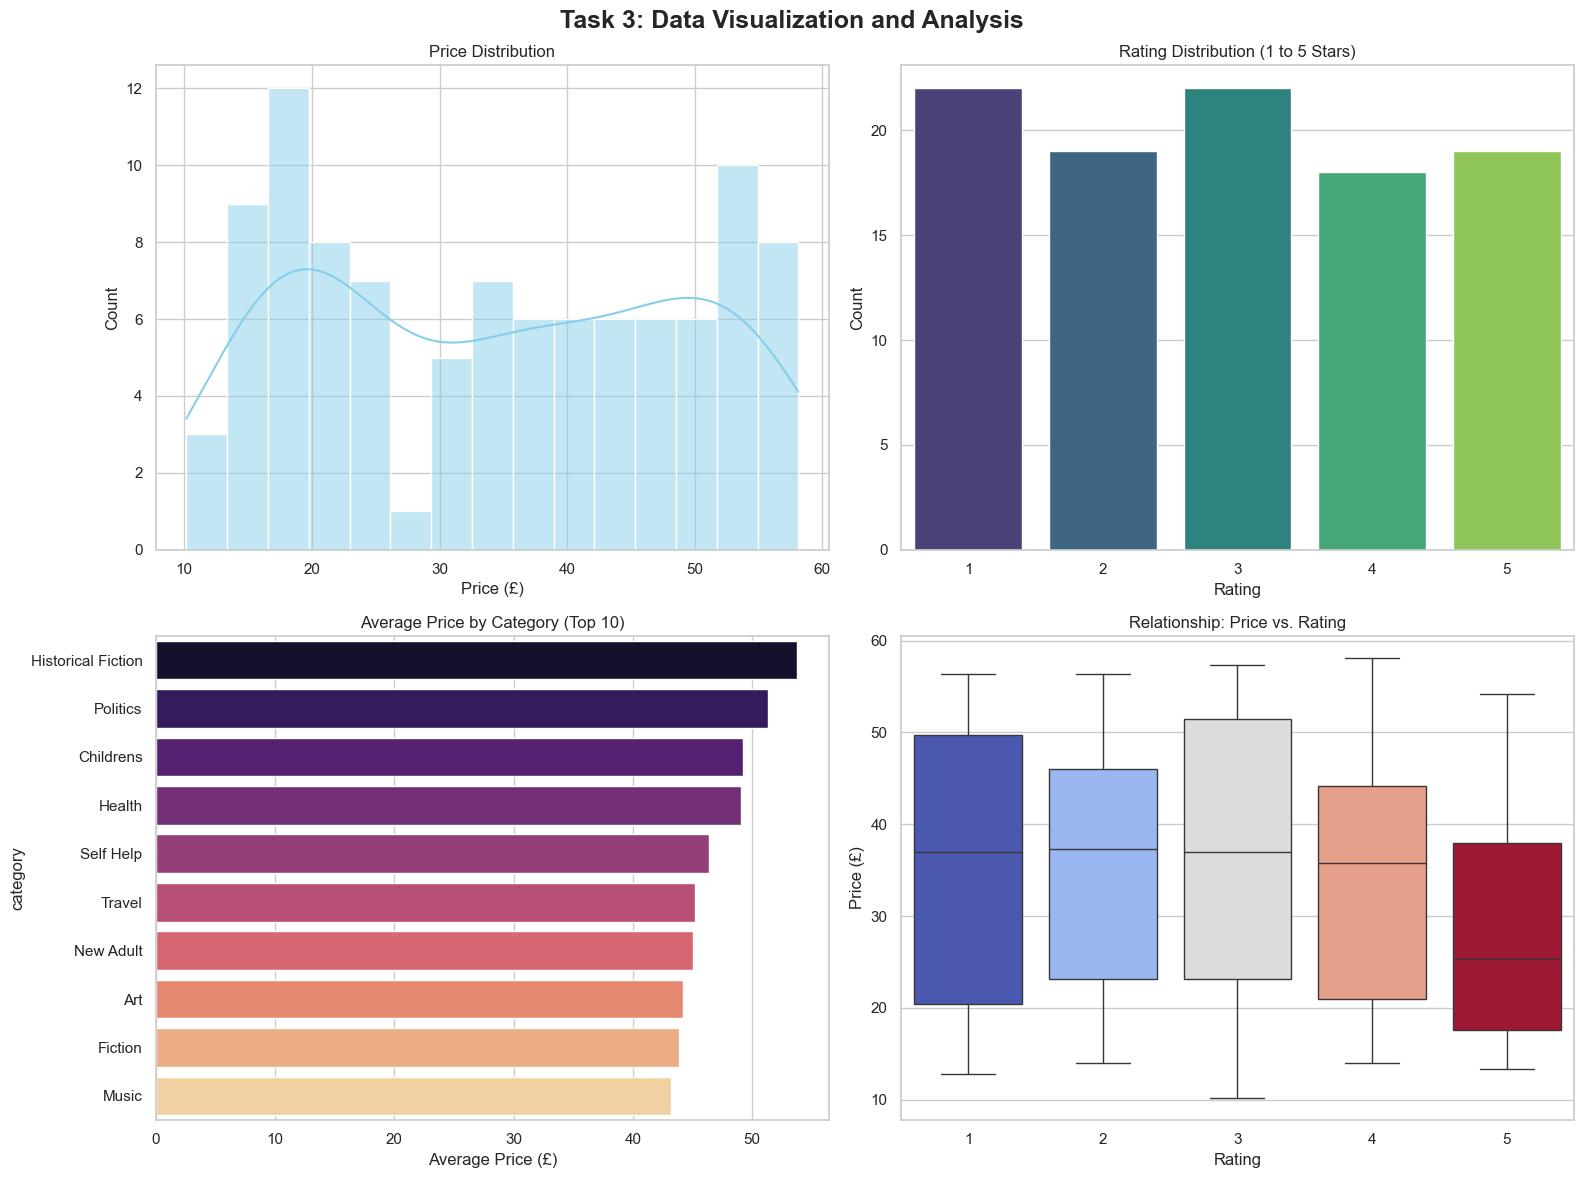


=== WORD CLOUD: BOOK DESCRIPTIONS ===


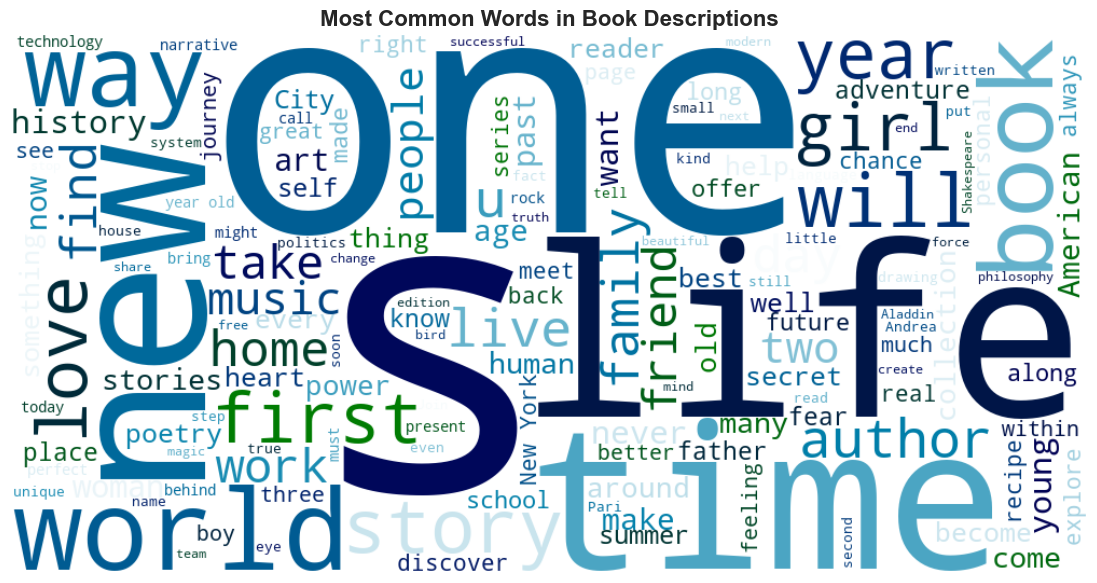

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from IPython.display import display

df = pd.read_csv('books_cleaned.csv')

print("=== SUMMARY STATISTICS ===")
display(df.describe())

# Overall averages
overall = pd.DataFrame({
    'Mean Price (£)': [df['price'].mean()],
    'Mean Rating': [df['rating'].mean()],
    'Mean Value Score': [df['value_score'].mean()],
    'Mean Stock': [df['stock_count'].mean()],
    'Mean Description Words': [df['description_word_count'].mean()]
})
display(overall.round(2))

# Price band summary
band_summary = (
    df.groupby('price_band', observed=False)
      .agg(
          Books=('title', 'count'),
          Mean_Price=('price', 'mean'),
          Mean_Rating=('rating', 'mean'),
          Mean_Value_Score=('value_score', 'mean')
      )
      .reset_index()
)

print("\n=== VALUE BY PRICE BAND ===")
display(band_summary.round(3))

# Category summary
category_summary = (
    df.groupby('category')
      .agg(
          Books=('title', 'count'),
          Mean_Price=('price', 'mean'),
          Mean_Rating=('rating', 'mean'),
          Mean_Value_Score=('value_score', 'mean')
      )
      .sort_values('Mean_Value_Score', ascending=False)
)

print("\n=== CATEGORY SUMMARY ===")
display(category_summary.round(3))

# Main charts
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Book Price, Rating and Value Analysis', fontsize=18, fontweight='bold')

sns.histplot(df['price'], bins=15, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (£)')

sns.countplot(x='rating', data=df, ax=axes[0, 1], hue='rating', legend=False)
axes[0, 1].set_title('Rating Distribution')
axes[0, 1].set_xlabel('Rating')
axes[0, 1].set_ylabel('Number of Books')

avg_price = df.groupby('category')['price'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=avg_price.values, y=avg_price.index, ax=axes[1, 0], hue=avg_price.index, legend=False)
axes[1, 0].set_title('Average Price by Category (Top 10)')
axes[1, 0].set_xlabel('Average Price (£)')
axes[1, 0].set_ylabel('Category')

sns.boxplot(x='rating', y='price', data=df, ax=axes[1, 1], hue='rating', legend=False)
axes[1, 1].set_title('Price by Rating')
axes[1, 1].set_xlabel('Rating')
axes[1, 1].set_ylabel('Price (£)')

plt.tight_layout()
plt.show()

# Value score by price band
plt.figure(figsize=(9, 5))
sns.barplot(data=band_summary, x='price_band', y='Mean_Value_Score', hue='price_band', legend=False)
plt.title('Average Value Score by Price Band')
plt.xlabel('Price Band')
plt.ylabel('Mean Value Score')
plt.tight_layout()
plt.show()

# Average value score by category
top_value_categories = category_summary.head(10).sort_values('Mean_Value_Score')

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Mean_Value_Score',
    y=top_value_categories.index,
    data=top_value_categories,
    hue=top_value_categories.index,
    legend=False
)
plt.title('Top 10 Categories by Average Value Score')
plt.xlabel('Mean Value Score')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# Word cloud
text = " ".join(df['product_description'].fillna('').astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=150
).generate(text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Book Descriptions', fontsize=16, fontweight='bold')
plt.show()

# A few numbers that can be used directly in the conclusion
best_band = band_summary.loc[band_summary['Mean_Value_Score'].idxmax()]
best_category = category_summary.iloc[0]
cheapest_category = category_summary.loc[category_summary['Mean_Price'].idxmin()]

print("\n=== KEY FINDINGS ===")
print(f"Overall mean price: £{df['price'].mean():.2f}")
print(f"Overall mean rating: {df['rating'].mean():.2f}")
print(f"Overall mean value score: {df['value_score'].mean():.3f}")
print(f"Best price band by value score: {best_band['price_band']} ({best_band['Mean_Value_Score']:.3f})")
print(f"Best category by value score: {category_summary.index[0]} ({best_category['Mean_Value_Score']:.3f})")
print(f"Lowest average-price category: {cheapest_category.name} (£{cheapest_category['Mean_Price']:.2f})")


## Conclusion and Further Analysis

The `value_score` was one of the most useful features in this analysis. The main reason for creating it was the assumption that a book with a higher price is not necessarily a better-rated book. By combining price and rating into a value score, we could compare books based on the rating they offer relative to their price. The results showed that the **Moderate price bracket had a better average value score than the Expensive bracket**. This suggests that paying more does not automatically mean getting a better-rated book, and that moderately priced books may provide better overall value.

However, this dataset is synthetic, so the results should not be treated as a strong prediction of real-world behaviour. The relatively even distribution across several features and the patterns visible in the plots suggest that the data does not fully represent a real e-commerce book catalogue. In a real online bookstore, there could be a much stronger relationship between price, ratings, popularity, and the number of reviews.

For a real e-commerce website, `value_score` could still be a useful metric for recommendations. Instead of showing books on the first page or in a "Top Sellers" section based only on rating, a website could consider **high rating combined with reasonable price**. This could help surface books that provide good value rather than simply books with the highest ratings.

The category-level pricing differences, such as **Historical Fiction and Politics having higher average prices than Music and Art**, are the results I would trust the least. There are only 100 books spread across many categories, meaning some categories contain only one or two books. A single expensive book can therefore have a large effect on the category average. If the dataset were expanded to 1,000 or more books per category, I would expect many of these category differences to become smaller and move closer to the overall average price of approximately **£34.56**, rather than keeping the same level of variation seen here.

The engineered `value_score` was particularly useful because it gives us a way to identify books that are **high-rated but relatively inexpensive**, rather than having to look at price and rating separately. If this project were extended, `value_score` could be combined with `description_word_count` to create a simple recommendation ranking. This could help identify books that have both strong value and detailed descriptions, although this would need to be tested on a much larger and more realistic dataset before drawing conclusions.

The `number_of_reviews` feature was another important finding. Since it is zero for all 100 books, it provides no useful variation for analysis in this dataset. This is a useful reminder when working with scraped data that a column should not automatically be treated as useful simply because it exists. Checking the variation and quality of scraped features early in the analysis can prevent misleading conclusions.

Finally, the **word cloud** provides a useful visual summary of the book descriptions. It allows us to quickly identify common keywords that appear frequently across the dataset and gives a simple overview of the themes and language used in the descriptions. This could be extended into further analysis by measuring the frequency of individual words and comparing them with features such as **rating, price, value score, or description word count**. For example, we could investigate whether books containing certain keywords tend to have higher ratings or better value scores. This could help identify relationships between the language used to describe a book and its performance-related features, providing another direction for future analysis.